In [2]:
import torch as th
import numpy as np
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
import psutil

In [3]:
# MADE USING CHATGPT , IDK how to make this
def measure_memory(func, *args, **kwargs):
    process = psutil.Process(os.getpid())
    start_mem = process.memory_info().rss / 1024 ** 2  # in MB
    start_time = time.time()
    result = func(*args, **kwargs)
    end_time = time.time()
    end_mem = process.memory_info().rss / 1024 ** 2  # in MB
    print(f"Memory Used: {end_mem - start_mem:.2f} MB")
    print(f"Execution Time: {end_time - start_time:.2f} seconds")
    return result

Pre-processing the dataset :-

In [4]:
data=pd.read_csv('data.csv')
data.drop(columns=['AppointmentID','AppointmentDay','Neighbourhood','ScheduledDay','PatientId'],inplace=True)
data['No-show']=data['No-show'].map({'No':0,'Yes':1})
data['Gender']=data['Gender'].map({'F':0,'M':1})
data['Age']=data['Age'].astype(np.float32)

In [5]:
print(data.describe())

              Gender            Age    Scholarship   Hipertension  \
count  110527.000000  110527.000000  110527.000000  110527.000000   
mean        0.350023      37.088875       0.098266       0.197246   
std         0.476979      23.110262       0.297675       0.397921   
min         0.000000      -1.000000       0.000000       0.000000   
25%         0.000000      18.000000       0.000000       0.000000   
50%         0.000000      37.000000       0.000000       0.000000   
75%         1.000000      55.000000       0.000000       0.000000   
max         1.000000     115.000000       1.000000       1.000000   

            Diabetes     Alcoholism        Handcap   SMS_received  \
count  110527.000000  110527.000000  110527.000000  110527.000000   
mean        0.071865       0.030400       0.022248       0.321026   
std         0.258265       0.171686       0.161543       0.466873   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.0000

Making the ANN using core python :- 

Task 1:-

In [6]:
data.shape

(110527, 9)

In [7]:
n_x=data.shape[1]-1
n_y=1
n_h=9
layer_dims=[n_x,n_h,n_y]

In [8]:
def sigmoid(x):
    cache=[]
    cache.append(x)
    return 1/(1+np.exp(-x)),cache

In [9]:
def relu(Z):
    cache=[]
    A=np.maximum(0,Z)
    cache.append(Z)
    return A,cache

In [10]:
def inipar(layer_dims):
    par={}
    np.random.seed(1)
    for l in range(1,len(layer_dims)):
        par['W'+str(l)]=np.random.randn(layer_dims[l],layer_dims[l-1])*0.01
        par['b'+str(l)]=np.zeros((layer_dims[l],1))
    return par

In [11]:
def linfo(A,W,b):
    Z=np.dot(W,A)+b
    cache=(A,W,b)
    return Z,cache

In [12]:
def linactfow(A_prev,W,b,act):
    lin_cache=(A_prev,W,b)
    z=np.dot(W,A_prev)+b
    if act=='sigmoid':
        a,act_cache=sigmoid(z)
    elif act=='relu':
        a,act_cache=relu(z)
    cache=(lin_cache,act_cache)
    return a,cache

In [13]:
def Lmodfow(X,par):
    caches=[]
    A=X
    L=len(par)//2
    for l in range(1,L):
        aprev=A
        A,cache=linactfow(aprev,par['W'+str(l)],par['b'+str(l)],'relu')
        caches.append(cache)
    AL,cache=linactfow(A,par['W'+str(L)],par['b'+str(L)],'sigmoid')
    caches.append(cache)
    return AL,caches

In [14]:
def cost(AL,Y):
    m=Y.shape[1]
    cost=-1/m*np.sum(Y*np.log(AL)+(1-Y)*np.log(1-AL))
    cost=np.squeeze(cost)
    return cost

In [15]:
def linback(dZ,cache):
    A_prev,W,b=cache
    m=A_prev.shape[1]
    dW=1/m*np.dot(dZ,A_prev.T)
    db=1/m*np.sum(dZ,axis=1,keepdims=True)
    dA_prev=np.dot(W.T,dZ)
    return dA_prev,dW,db

In [16]:
def sigback(dA,cache):
    Z=cache[0]
    s=1/(1+np.exp(-Z))
    dZ=dA*s*(1-s)
    return dZ

In [17]:
def relback(dA,cache):
    Z=cache[0]
    dZ=np.array(dA,copy=True)
    dZ[Z<=0]=0
    return dZ

In [18]:
def linactback(dA,cache,act):
    lin_cache,act_cache=cache
    if act=='sigmoid':
        dZ=sigback(dA,act_cache)
    elif act=='relu':
        dZ=relback(dA,act_cache)
    dA_prev,dW,db=linback(dZ,lin_cache)
    return dA_prev,dW,db

In [19]:
def lmodback(AL,Y,caches):
    grads={}
    L=len(caches)
    m=AL.shape[1]
    Y=Y.reshape(AL.shape)
    dAL=-(np.divide(Y,AL)-np.divide(1-Y,1-AL))
    current_cache=caches[L-1]
    grads['dA'+str(L)],grads['dW'+str(L)],grads['db'+str(L)]=linactback(dAL,current_cache,'sigmoid')
    for l in reversed(range(L-1)):
        current_cache=caches[l]
        dA_prev_temp,dW_temp,db_temp=linactback(grads["dA" + str(l + 2)],current_cache,'relu')
        grads["dA"+str(l + 1)]=dA_prev_temp
        grads["dW"+str(l + 1)]=dW_temp
        grads["db"+str(l + 1)]=db_temp
    return grads

In [20]:
def updpar(par,grads,learnrate):
    L=len(par)//2
    for l in range(L):
        par['W'+str(l+1)]=par['W'+str(l+1)]-learnrate*grads['dW'+str(l+1)]
        par['b'+str(l+1)]=par['b'+str(l+1)]-learnrate*grads['db'+str(l+1)]
    return par

In [21]:
def Llaymod(X,Y,layer_dims,learnrate=0.01,num_iter=1000):
    np.random.seed(1)
    costs=[]
    par=inipar(layer_dims)
    for i in range(0,num_iter):
        AL,caches=Lmodfow(X,par)
        cst=cost(AL,Y)
        grads=lmodback(AL,Y,caches)
        par=updpar(par,grads,learnrate)
        if i%100==0:
            costs.append(cst)
            print("Cost after iteration %i: %f" % (i,cst))
    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('iterations (per tens)')
    plt.title("Learning rate =" + str(learnrate))
    plt.show()
    return par,costs

In [22]:
a=data.to_numpy()

In [23]:
print(a)

[[ 0. 62.  0. ...  0.  0.  0.]
 [ 1. 56.  0. ...  0.  0.  0.]
 [ 0. 62.  0. ...  0.  0.  0.]
 ...
 [ 0. 21.  0. ...  0.  1.  0.]
 [ 0. 38.  0. ...  0.  1.  0.]
 [ 0. 54.  0. ...  0.  1.  0.]]


In [24]:
print(data.head())

   Gender   Age  Scholarship  Hipertension  Diabetes  Alcoholism  Handcap  \
0       0  62.0            0             1         0           0        0   
1       1  56.0            0             0         0           0        0   
2       0  62.0            0             0         0           0        0   
3       0   8.0            0             0         0           0        0   
4       0  56.0            0             1         1           0        0   

   SMS_received  No-show  
0             0        0  
1             0        0  
2             0        0  
3             0        0  
4             0        0  


In [25]:
X=a[:,0:8].T
Y=a[:,8].reshape(1,a.shape[0])

In [26]:
print(Y)

[[0. 0. 0. ... 0. 0. 0.]]


In [27]:
print(X.shape)
print(Y.shape)

(8, 110527)
(1, 110527)


Cost after iteration 0: 0.694148
Cost after iteration 100: 0.526908
Cost after iteration 200: 0.524105
Cost after iteration 300: 0.521625
Cost after iteration 400: 0.519430
Cost after iteration 500: 0.517484
Cost after iteration 600: 0.515756
Cost after iteration 700: 0.514220
Cost after iteration 800: 0.512854
Cost after iteration 900: 0.511637


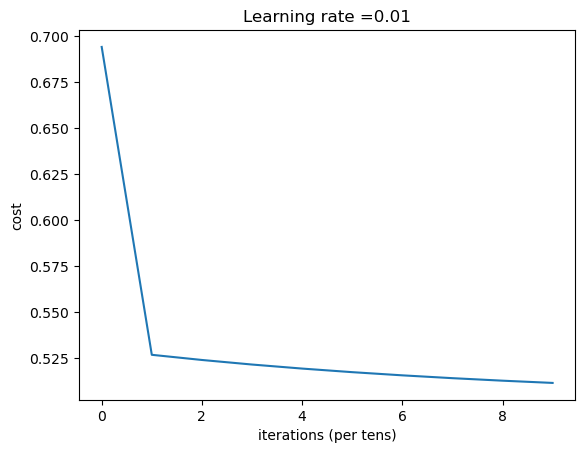

Execution time: 13.28 seconds


In [28]:
st=time.time()
par,costs=Llaymod(X,Y,layer_dims,learnrate=0.01,num_iter=1000)
et=time.time()
print(f"Execution time: {et-st:.2f} seconds")

In [29]:
def predict(tx,ty,par):
    m=tx.shape[1]
    p=np.zeros((1,m))
    AL,caches=Lmodfow(tx,par)
    for i in range(0,AL.shape[1]):
        if AL[0,i]>=0.24:
            p[0,i]=1
        else:
            p[0,i]=0
    print("Accuracy: "  + str(np.sum((p==ty)/m)))
    return p

In [30]:
pt=predict(X,Y,par)
llll=[]
Al,cahc=Lmodfow(X,par)
for i in range(0,Al.shape[1]):
    if Y[0,i]==1:
        llll.append(Al[0,i])

Accuracy: 0.5601708179901744


Cost after iteration 0: 0.694148
Cost after iteration 100: 0.526908
Cost after iteration 200: 0.524105
Cost after iteration 300: 0.521625
Cost after iteration 400: 0.519430
Cost after iteration 500: 0.517484
Cost after iteration 600: 0.515756
Cost after iteration 700: 0.514220
Cost after iteration 800: 0.512854
Cost after iteration 900: 0.511637


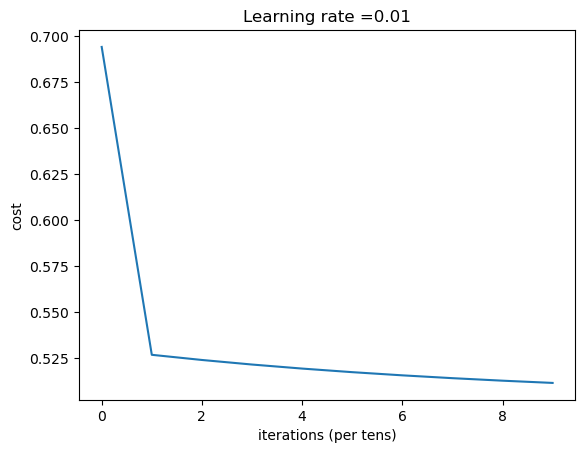

Memory Usage: 44.45 MB


In [31]:
process = psutil.Process(os.getpid())

start_mem = process.memory_info().rss / 1024**2  # in MB    

par, costs = Llaymod(X, Y, layer_dims, learnrate=0.01, num_iter=1000)

end_mem = process.memory_info().rss / 1024**2  # in MB

print(f"Memory Usage: {end_mem - start_mem:.2f} MB")


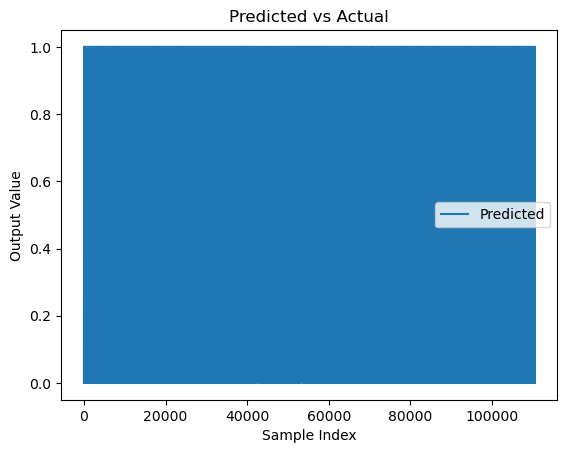

In [32]:
plt.plot(pt.T, label='Predicted')
plt.legend()
plt.title('Predicted vs Actual')
plt.xlabel('Sample Index')
plt.ylabel('Output Value')
plt.show()

Now using PyTorch for this :- 

Part 2:-

In [33]:
import torch.nn as nn
import torch.optim as optim
import torch

In [34]:
class ANN(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super(ANN,self).__init__()
        self.fc1=nn.Linear(input_size,hidden_size)
        self.relu=nn.ReLU()
        self.fc2=nn.Linear(hidden_size,output_size)

    def forward(self,x):
        x=self.fc1(x)
        x=self.relu(x)
        x=self.fc2(x)
        return x

In [35]:
n_x=data.shape[1]-1
n_h=9
n_y=1

model=ANN(n_x,n_h,n_y)
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

In [36]:
X_train=th.from_numpy(X.T).float()
y_train=th.from_numpy(Y.T).float()

In [37]:
criterion = nn.BCELoss()  # Using Binary Cross Entropy Loss

process2 = psutil.Process(os.getpid())

stm = process2.memory_info().rss / 1024**2  # in MB
eplist = []
stt = time.time()
losslist = []

for epoch in range(1000):
    outputs = model(X_train)
    outputs = torch.sigmoid(outputs)  # Make sure outputs are probabilities

    y_train = y_train.view(-1, 1).float()  # Reshape and cast

    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        eplist.append(epoch+1)
        losslist.append(loss.item())
        print(f'Epoch [{epoch+1}/1000], Loss: {loss.item():.4f}')

ent = time.time()
print(f"Execution time: {ent-stt:.2f} seconds")

etm = process2.memory_info().rss / 1024**2  # in MB
print(f"Memory usage: {etm-stm:.2f} MB")


Epoch [10/1000], Loss: 0.5467
Epoch [20/1000], Loss: 0.5326
Epoch [30/1000], Loss: 0.5214
Epoch [40/1000], Loss: 0.5120
Epoch [50/1000], Loss: 0.5065
Epoch [60/1000], Loss: 0.5021
Epoch [70/1000], Loss: 0.4972
Epoch [80/1000], Loss: 0.4940
Epoch [90/1000], Loss: 0.4923
Epoch [100/1000], Loss: 0.4916
Epoch [110/1000], Loss: 0.4915
Epoch [120/1000], Loss: 0.4914
Epoch [130/1000], Loss: 0.4914
Epoch [140/1000], Loss: 0.4914
Epoch [150/1000], Loss: 0.4913
Epoch [160/1000], Loss: 0.4913
Epoch [170/1000], Loss: 0.4913
Epoch [180/1000], Loss: 0.4913
Epoch [190/1000], Loss: 0.4913
Epoch [200/1000], Loss: 0.4912
Epoch [210/1000], Loss: 0.4912
Epoch [220/1000], Loss: 0.4912
Epoch [230/1000], Loss: 0.4912
Epoch [240/1000], Loss: 0.4912
Epoch [250/1000], Loss: 0.4912
Epoch [260/1000], Loss: 0.4912
Epoch [270/1000], Loss: 0.4912
Epoch [280/1000], Loss: 0.4912
Epoch [290/1000], Loss: 0.4912
Epoch [300/1000], Loss: 0.4912
Epoch [310/1000], Loss: 0.4912
Epoch [320/1000], Loss: 0.4912
Epoch [330/1000],

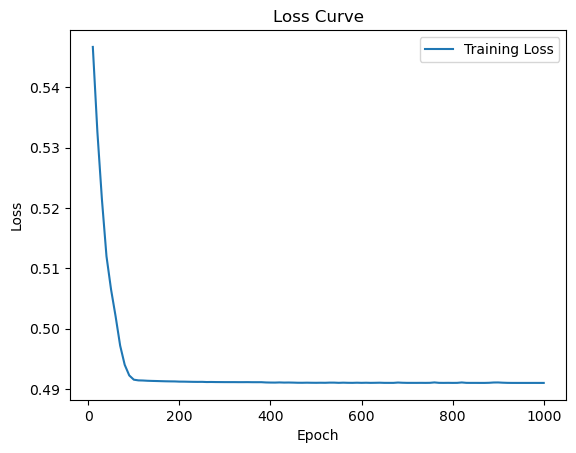

In [38]:
import matplotlib.pyplot as plt

plt.plot(eplist, losslist, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

In [39]:
model.eval()
with th.no_grad():
    y_pred = model(X_train)
    print(y_pred)
    y_pred = (y_pred > 0.24).float()
    accuracy = (y_pred.eq(y_train).sum().item()) / y_train.size(0)
    print(f'Accuracy: {accuracy}')

tensor([[-1.8325],
        [-1.7215],
        [-1.8412],
        ...,
        [-0.6172],
        [-0.9220],
        [-1.2088]])
Accuracy: 0.798067440534892


In [40]:
from sklearn.metrics import f1_score

In [41]:
f1_score(y_train.numpy(), y_pred.numpy(), average='weighted')

0.7084402122897501

In [42]:
f1_score(y_train.numpy(), pt.T, average='weighted')

0.6031648484632608

In [43]:
y_train.shape

torch.Size([110527, 1])

In [44]:
pt.shape

(1, 110527)

In [45]:
from sklearn.metrics import precision_recall_curve, auc

In [46]:
precision, recall, _ = precision_recall_curve(y_train.numpy(), y_pred.numpy())
pr_auc = auc(recall, precision)
print(f"PR AUC , PyTorch: {pr_auc:.4f}")

PR AUC , PyTorch: 0.6010


In [47]:
precision, recall, _ = precision_recall_curve(y_train.numpy(), pt.T)
pr_auc = auc(recall, precision)
print(f"PR AUC , manual interpretation: {pr_auc:.4f}")

PR AUC , manual interpretation: 0.4148


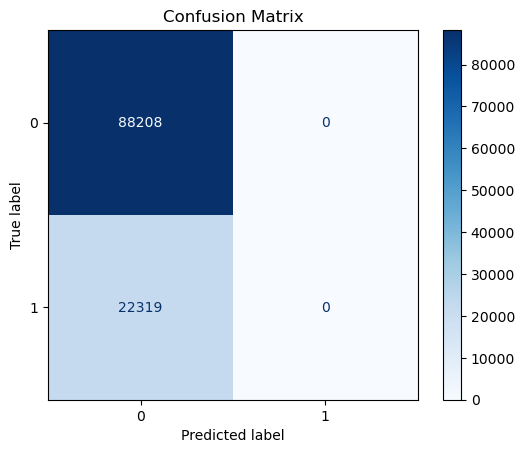

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


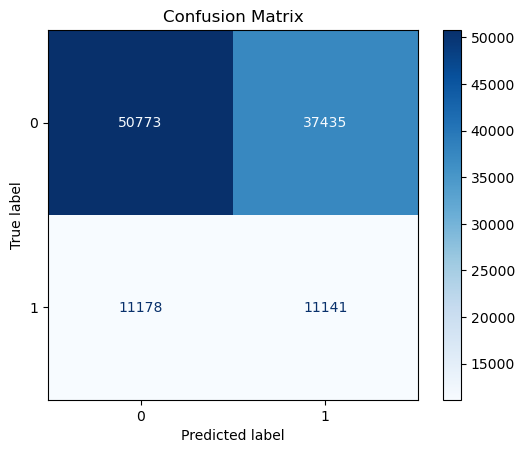

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_manual = confusion_matrix(y_train, pt.T)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_manual)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
